voice_gen_pipeline_architecture.svg

In [ ]:
# Verify GPU + mount Drive (optional but useful for saving checkpoints later)
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

from google.colab import drive
drive.mount('/content/drive')

GPU: None
Mounted at /content/drive


In [ ]:
%%capture
!pip install librosa soundfile datasets torchaudio matplotlib \
            seaborn pandas numpy kaggle

In [ ]:
!wget -q https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2
!tar -xjf LJSpeech-1.1.tar.bz2
# structure: LJSpeech-1.1/wavs/*.wav  +  metadata.csv

In [ ]:
import pandas as pd

# LJSpeech metadata
df = pd.read_csv('LJSpeech-1.1/metadata.csv', sep='|',
                 header=None,
                 names=['id', 'transcript', 'normalized'])
df['wav_path'] = 'LJSpeech-1.1/wavs/' + df['id'] + '.wav'
df['text_len'] = df['normalized'].str.len()
print(df.shape)
df.head(3)

(13100, 5)


,id,transcript,normalized,wav_path,text_len
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...",LJSpeech-1.1/wavs/LJ001-0001.wav,151.0
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,LJSpeech-1.1/wavs/LJ001-0002.wav,30.0
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,LJSpeech-1.1/wavs/LJ001-0003.wav,155.0


In [ ]:
import librosa, numpy as np
from tqdm import tqdm

def get_stats(path):
    y, sr = librosa.load(path, sr=None)
    return {'sr': sr,
            'duration': len(y) / sr,
            'rms': float(np.sqrt(np.mean(y**2))),
            'samples': len(y)}

sample = df.sample(500, random_state=42)
stats = [get_stats(p) for p in tqdm(sample['wav_path'])]
stats_df = pd.DataFrame(stats)
stats_df.describe()

100%|██████████| 500/500 [00:27<00:00, 17.92it/s]


,sr,duration,rms,samples
count,500.0,500.000000,500.000000,500.000000
mean,22050.0,6.539799,0.066265,144202.568000
std,0.0,2.126349,0.009895,46885.993598
min,22050.0,1.110068,0.042680,24477.000000
25%,22050.0,5.074875,0.059205,111901.000000
50%,22050.0,6.764127,0.065483,149149.000000
75%,22050.0,8.241497,0.072341,181725.000000
max,22050.0,10.084580,0.107587,222365.000000


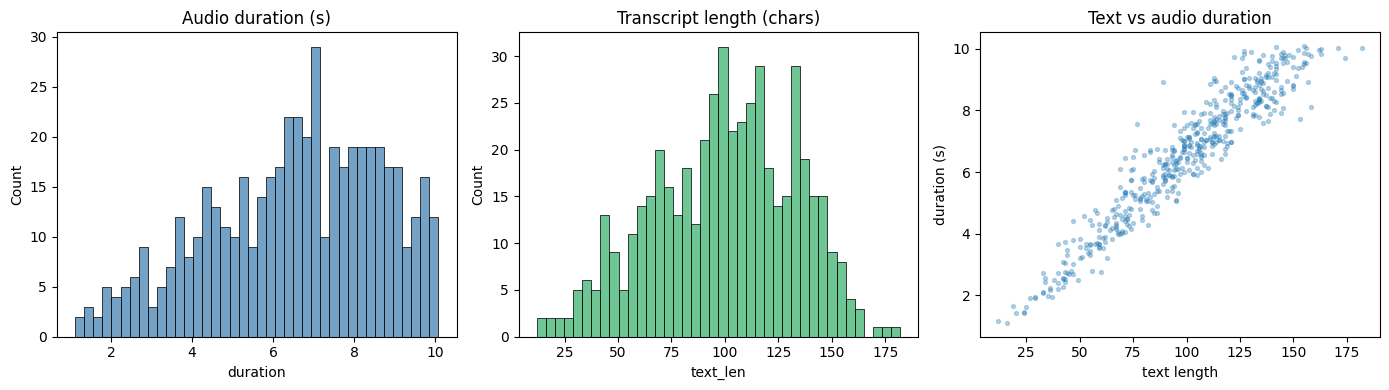

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(stats_df['duration'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Audio duration (s)')

sns.histplot(sample['text_len'], bins=40, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Transcript length (chars)')

axes[2].scatter(sample['text_len'].values,
                stats_df['duration'].values, alpha=0.3, s=8)
axes[2].set_xlabel('text length'); axes[2].set_ylabel('duration (s)')
axes[2].set_title('Text vs audio duration')

plt.tight_layout(); plt.show()

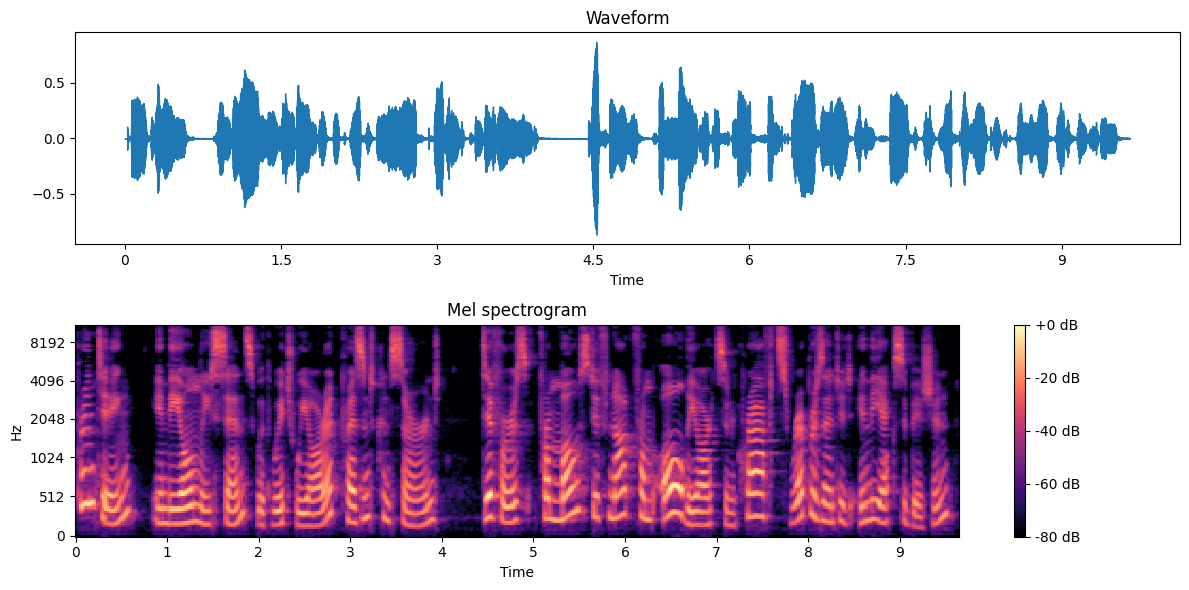

In [ ]:
import librosa.display

path = df['wav_path'].iloc[0]
y, sr = librosa.load(path, sr=None)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title('Waveform')

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time',
                         y_axis='mel', ax=axes[1])
axes[1].set_title('Mel spectrogram')
fig.colorbar(axes[1].collections[0], ax=axes[1], format='%+2.0f dB')

plt.tight_layout(); plt.show()

In [ ]:
merged = sample.reset_index(drop=True)
merged['duration'] = stats_df['duration']
merged['rms']      = stats_df['rms']

before = len(merged)
clean = merged[
    (merged['duration'] >= 1.0) &   # drop very short
    (merged['duration'] <= 12.0) &  # drop very long
    (merged['rms']      >= 0.005)   # drop near-silent
]
print(f"Kept {len(clean)}/{before} clips ({len(clean)/before:.1%})")

Kept 500/500 clips (100.0%)


In [ ]:
import pandas as pd

# reload full metadata
df_full = pd.read_csv('LJSpeech-1.1/metadata.csv', sep='|', header=None,
                      names=['id','transcript','normalized'])
df_full['wav_path'] = 'LJSpeech-1.1/wavs/' + df_full['id'] + '.wav'
df_full['text_len'] = df_full['normalized'].str.len()

# apply filters on full set (no audio stats needed — LJSpeech is already clean)
clean_full = df_full[
    (df_full['text_len'] >= 5) &    # drop near-empty transcripts
    (df_full['text_len'] <= 190)    # drop outlier-long ones
]

clean_full[['id','wav_path','normalized','text_len']]\
    .to_csv('manifest_clean.csv', index=False)

print(f"{len(clean_full)}/{len(df_full)} clips kept ({len(clean_full)/len(df_full):.1%})")

13084/13100 clips kept (99.9%)


Splitting Data


In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/manifest_clean.csv')

# first split off test (10%)
train_val, test = train_test_split(df, test_size=0.10, random_state=42)

# then split train/val from the remaining 90%
train, val = train_test_split(train_val, test_size=0.111, random_state=42)
# 0.111 of 90% ≈ 10% of total → gives you 80/10/10

print(f"train : {len(train):,}")
print(f"val   : {len(val):,}")
print(f"test  : {len(test):,}")

train.to_csv('/content/train.csv', index=False)
val.to_csv('/content/val.csv',   index=False)
test.to_csv('/content/test.csv',  index=False)

train : 10,467
val   : 1,308
test  : 1,309


Audio Encoder

In [ ]:
%%capture
!pip install transformers datasets accelerate \
            torchaudio soundfile librosa \
            tensorboard evaluate jiwer torchinfo

In [ ]:
MODEL_ID      = "openai/whisper-small"
TRAIN_CSV     = "/content/train.csv"
VAL_CSV       = "/content/val.csv"
WAV_ROOT      = ""              # paths in csv are already relative to /content
OUTPUT_DIR    = "/content/whisper-finetuned"
SAMPLE_RATE   = 16000            # whisper expects 16kHz (not 22050)
MAX_DURATION  = 30               # whisper hard limit (seconds)
BATCH_SIZE    = 8                # safe for T4 16GB with grad checkpointing
GRAD_ACCUM    = 4                # effective batch = 32
LR            = 1e-5
WARMUP_STEPS  = 500
MAX_STEPS     = 4000
SAVE_STEPS    = 500
EVAL_STEPS    = 500
FP16          = True

In [ ]:
# Removed WhisperForConditionalGeneration model loading and summary as per user's request.
# We are now building a custom autoencoder from scratch.

import torch
import torch.nn as nn
from torchinfo import summary

# These parameters were defined for Whisper's summary, but are still relevant for our custom models.
batch        = 1
mel_bins     = 80
time_frames  = 3000   # 30s audio at 100 frames/sec

### Custom PyTorch Encoder

Here is a basic custom encoder built with PyTorch's `nn.Module`. This serves as a placeholder and demonstrates how you could define your own encoder architecture. It includes convolutional layers for feature extraction and a simple Transformer Encoder block, mimicking some aspects of typical audio encoders.

In [ ]:
import torch
import torch.nn as nn

class CustomEncoder(nn.Module):
    def __init__(self, num_mel_bins=80, hidden_dim=768, num_layers=2, nhead=8):
        super().__init__()

        # Initial convolutional layers, similar to Whisper's feature extractor
        self.conv1 = nn.Conv1d(num_mel_bins, hidden_dim, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        # Downsample the time dimension by 2
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, stride=2, padding=1)
        self.relu2 = nn.ReLU()

        # Transformer Encoder layers
        # The input to TransformerEncoderLayer should be (batch_size, sequence_length, feature_dimension)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            batch_first=True,
            activation='relu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, input_features):
        # input_features: (batch_size, num_mel_bins, time_frames)

        x = self.conv1(input_features)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.relu2(x)

        # Permute to (batch_size, sequence_length, feature_dimension) for TransformerEncoder
        x = x.permute(0, 2, 1)

        encoded_features = self.transformer_encoder(x)
        return encoded_features

### Custom PyTorch Decoder

This `CustomDecoder` aims to reverse the operations of the `CustomEncoder` to reconstruct the original mel-spectrograms. It uses `ConvTranspose1d` layers for upsampling.

In [ ]:
import torch
import torch.nn as nn

class CustomDecoder(nn.Module):
    def __init__(self, num_mel_bins=80, hidden_dim=768, num_layers=2, nhead=8):
        super().__init__()

        # Transformer Decoder layers (using EncoderLayer for symmetric architecture in this autoencoder setup)
        # Input to this transformer will be (batch_size, sequence_length, hidden_dim)
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            batch_first=True,
            activation='relu'
        )
        self.transformer_decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)

        # Reverse convolutional layers
        # deconv1 reverses encoder's conv2 (upsampling stride=2)
        # output_padding=1 is crucial to ensure correct output size matching the input of encoder's conv2
        self.deconv1 = nn.ConvTranspose1d(hidden_dim, hidden_dim, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.relu1 = nn.ReLU()

        # deconv2 reverses encoder's conv1 (channel change)
        self.deconv2 = nn.ConvTranspose1d(hidden_dim, num_mel_bins, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU() # Apply activation for consistency with encoder

    def forward(self, latent_representation):
        # latent_representation: (batch_size, sequence_length, hidden_dim) where sequence_length is time_frames / 2

        x = self.transformer_decoder(latent_representation)

        # Permute back to (batch_size, hidden_dim, sequence_length) for ConvTranspose1d
        x = x.permute(0, 2, 1)

        x = self.deconv1(x)
        x = self.relu1(x)
        reconstructed_features = self.deconv2(x)
        reconstructed_features = self.relu2(reconstructed_features) # Apply activation for consistency

        return reconstructed_features

### Custom Autoencoder

This class combines the `CustomEncoder` and `CustomDecoder` to form a complete autoencoder. It takes mel-spectrogram features as input, encodes them into a latent representation, and then decodes them back into reconstructed mel-spectrograms.

In [ ]:
class CustomAutoencoder(nn.Module):
    def __init__(self, num_mel_bins=80, hidden_dim=768, encoder_layers=6, decoder_layers=2, nhead=12):
        super().__init__()
        self.encoder = CustomEncoder(num_mel_bins, hidden_dim, encoder_layers, nhead)

    def forward(self, input_features):
        latent_representation = self.encoder(input_features)
        # Returning latent representation directly since decoder is removed
        return latent_representation

I'll now modify the `CustomAutoencoder` class to integrate the `CustomDecoder`.

In [ ]:
class CustomAutoencoder(nn.Module):
    def __init__(self, num_mel_bins=80, hidden_dim=768, encoder_layers=6, decoder_layers=2, nhead=12):
        super().__init__()
        self.encoder = CustomEncoder(num_mel_bins, hidden_dim, encoder_layers, nhead)
        self.decoder = CustomDecoder(num_mel_bins, hidden_dim, decoder_layers, nhead) # Re-introducing decoder

    def forward(self, input_features):
        latent_representation = self.encoder(input_features)
        reconstructed_features = self.decoder(latent_representation)
        return reconstructed_features

In [ ]:
# Instantiate the CustomAutoencoder
# We'll use values consistent with the 'small' Whisper model's core dimensions
# for hidden_dim, encoder_layers, and nhead for initial setup.
autoencoder_model = CustomAutoencoder(
    num_mel_bins=mel_bins,
    hidden_dim=768,        # d_model for whisper-small
    encoder_layers=6,      # encoder_layers for whisper-small
    decoder_layers=2,      # A simpler decoder for reconstruction
    nhead=12               # encoder_attention_heads for whisper-small
)

# Print its summary using torchinfo
print("\n--- Custom Autoencoder Summary ---")
summary(
    autoencoder_model,
    input_data={
        "input_features": torch.zeros(batch, mel_bins, time_frames),
    },
    col_names=["input_size", "output_size", "num_params", "trainable"],
    row_settings=["var_names"],
    depth=4,
    verbose=1,
)


--- Custom Autoencoder Summary ---
Layer (type (var_name))                                      Input Shape               Output Shape              Param #                   Trainable
CustomAutoencoder (CustomAutoencoder)                        --                        [1, 80, 3000]             --                        True
├─CustomEncoder (encoder)                                    [1, 80, 3000]             [1, 1500, 768]            --                        True
│    └─Conv1d (conv1)                                        [1, 80, 3000]             [1, 768, 3000]            185,088                   True
│    └─ReLU (relu1)                                          [1, 768, 3000]            [1, 768, 3000]            --                        --
│    └─Conv1d (conv2)                                        [1, 768, 3000]            [1, 768, 1500]            1,770,240                 True
│    └─ReLU (relu2)                                          [1, 768, 1500]            [1, 768, 1

Layer (type (var_name))                                      Input Shape               Output Shape              Param #                   Trainable
CustomAutoencoder (CustomAutoencoder)                        --                        [1, 80, 3000]             --                        True
├─CustomEncoder (encoder)                                    [1, 80, 3000]             [1, 1500, 768]            --                        True
│    └─Conv1d (conv1)                                        [1, 80, 3000]             [1, 768, 3000]            185,088                   True
│    └─ReLU (relu1)                                          [1, 768, 3000]            [1, 768, 3000]            --                        --
│    └─Conv1d (conv2)                                        [1, 768, 3000]            [1, 768, 1500]            1,770,240                 True
│    └─ReLU (relu2)                                          [1, 768, 1500]            [1, 768, 1500]            --                  

In [ ]:
import inspect
from transformers.models.whisper.modeling_whisper import (
    WhisperEncoder,
    WhisperPreTrainedModel
)
from transformers.modeling_utils import PreTrainedModel
import torch.nn as nn

classes = [
    WhisperEncoder,
    WhisperPreTrainedModel,
    PreTrainedModel,
    nn.Module,
]

for cls in classes:
    print(f"CLASS: {cls.__name__}  |  defined in: {inspect.getfile(cls)}")
    # print only the class signature + __init__ to keep output manageable
    source = inspect.getsource(cls)
    # print first 40 lines only — enough to see the class def + __init__
    lines = source.split('\n')
    print('\n'.join(lines[:40]))
    print("... (truncated)")

CLASS: WhisperEncoder  |  defined in: /usr/local/lib/python3.12/dist-packages/transformers/models/whisper/modeling_whisper.py
class WhisperEncoder(WhisperPreTrainedModel):
    """
    Transformer encoder consisting of *config.encoder_layers* self attention layers. Each layer is a
    [`WhisperEncoderLayer`].

    Args:
        config: WhisperConfig
    """

    _can_record_outputs = {
        "hidden_states": WhisperEncoderLayer,
        "attentions": WhisperAttention,
    }
    input_modalities = ("audio",)

    def __init__(self, config: WhisperConfig):
        super().__init__(config)
        self.dropout = config.dropout
        self.layerdrop = config.encoder_layerdrop

        embed_dim = config.d_model
        self.num_mel_bins = config.num_mel_bins
        self.padding_idx = config.pad_token_id
        self.max_source_positions = config.max_source_positions
        self.embed_scale = math.sqrt(embed_dim) if config.scale_embedding else 1.0

        self.conv1 = nn.Conv1d(self.nu

In [ ]:
import torch, torchaudio, pandas as pd
from torch.utils.data import Dataset
from transformers import WhisperProcessor

# Note: processor is still used here for feature extraction to ensure consistency
# with mel-spectrogram generation parameters used previously, even though
# we're not doing speech-to-text directly.
processor = WhisperProcessor.from_pretrained(MODEL_ID)
resampler = torchaudio.transforms.Resample(22050, SAMPLE_RATE)

class LJSpeechDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        wav, sr = torchaudio.load(f"/content/{row['wav_path']}")
        wav  = resampler(wav).squeeze(0)          # mono, 16kHz

        # For autoencoder, input_features are also the labels (target for reconstruction)
        input_features = processor(
            wav.numpy(), sampling_rate=SAMPLE_RATE,
            return_tensors="pt", padding="max_length",
            truncation=True, max_length=SAMPLE_RATE * MAX_DURATION
        ).input_features.squeeze(0)

        return {
            "input_features": input_features,
            "labels"        : input_features, # Labels are the input features for autoencoding
        }

train_ds = LJSpeechDataset(TRAIN_CSV)
val_ds   = LJSpeechDataset(VAL_CSV)
print(f"train: {len(train_ds)} | val: {len(val_ds)}")

train: 10467 | val: 1308


In [ ]:
# Removed Whisper model loading and configuration as per user's request.
# The 'model' variable is now replaced with our 'autoencoder_model'.
model = autoencoder_model

In [ ]:
# All parameters of the CustomAutoencoder are trainable by default.
# If you wish to freeze specific layers within the CustomAutoencoder (e.g., its conv layers in the encoder),
# you would add similar freezing logic here, targeting autoencoder_model.encoder.conv1.parameters(), etc.

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M params")

trainable: 48.0M / 48.0M params


In [ ]:
from dataclasses import dataclass
from typing import List, Dict
import torch

@dataclass
class DataCollator:
    # For an autoencoder, the processor is mainly used for consistent feature extraction,
    # but for labels (which are now input features), we don't need tokenizer specific padding logic.
    # We'll keep a placeholder `processor` parameter in init for compatibility if needed, but it won't be used for labels.
    processor: object = None

    def __call__(self, features: List[Dict]) -> Dict:
        input_feats = torch.stack([f["input_features"] for f in features])
        labels      = torch.stack([f["labels"]          for f in features]) # labels are now also input_features

        # For autoencoders, we don't typically replace padding with -100 for a reconstruction loss
        # unless a specific masking strategy is employed. The loss function will handle padding if present.

        return {"input_features": input_feats, "labels": labels}

# We pass processor=None as its tokenizer part is not used for labels in the autoencoder context
collator = DataCollator(processor=None)

In [ ]:
import torch.nn.functional as F

# For an autoencoder reconstructing features, we use a reconstruction loss
# (e.g., Mean Squared Error or L1 loss) instead of WER.
# We'll define a simple MSE-based metric.

def compute_metrics(pred):
    # pred.predictions will be the reconstructed features (output of the decoder)
    # pred.label_ids will be the original input features (our target)

    # Ensure tensors are on the correct device if needed, though Trainer should handle this.
    # Also, ensure they are of the same shape and type.
    reconstructed_features = torch.tensor(pred.predictions)
    original_features = torch.tensor(pred.label_ids)

    # Calculate Mean Squared Error (MSE) as the reconstruction loss
    # Flatten the tensors to compute MSE across all elements
    mse_loss = F.mse_loss(
        reconstructed_features.view(reconstructed_features.size(0), -1),
        original_features.view(original_features.size(0), -1),
        reduction='mean'
    )

    return {"mse_loss": mse_loss.item()}

In [ ]:
from transformers import Trainer, TrainingArguments
from torch import nn

# Wrapper class for CustomAutoencoder to make it compatible with Trainer
class AutoencoderModelForTraining(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        self.autoencoder = autoencoder
        self.loss_fct = nn.MSELoss()

    def forward(self, input_features, labels=None, **kwargs):
        # input_features: (batch_size, num_mel_bins, time_frames)
        # labels: (batch_size, num_mel_bins, time_frames) - same as input_features for AE

        reconstructed_features = self.autoencoder(input_features)

        if labels is not None:
            loss = self.loss_fct(reconstructed_features, labels)
            return {"loss": loss, "reconstructed_features": reconstructed_features}

        return {"reconstructed_features": reconstructed_features}

# Instantiate the training wrapper
model_for_training = AutoencoderModelForTraining(autoencoder_model)

args = TrainingArguments(
    output_dir             = OUTPUT_DIR,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate          = LR,
    warmup_steps           = WARMUP_STEPS,
    max_steps              = MAX_STEPS,
    fp16                   = FP16,
    eval_strategy          = "steps",
    eval_steps             = EVAL_STEPS,
    save_steps             = SAVE_STEPS,
    logging_steps          = 25,
    # predict_with_generate is for generation tasks, not reconstruction
    # generation_max_length is for generation tasks
    load_best_model_at_end = True,
    metric_for_best_model  = "mse_loss", # Use our custom MSE metric
    greater_is_better      = False,    # Lower MSE is better
    report_to              = "tensorboard",
)

trainer = Trainer(
    model          = model_for_training, # Use our wrapped model
    args           = args,
    train_dataset  = train_ds,
    eval_dataset   = val_ds,
    data_collator  = collator,
    compute_metrics= compute_metrics, # Use our custom MSE compute_metrics
)

trainer.train()


Step,Training Loss,Validation Loss,Mse Loss,Runtime,Samples Per Second,Steps Per Second
500,1.685694,0.419556,0.419556,65.863500,19.859000,2.490000


Step,Training Loss,Validation Loss,Mse Loss,Runtime,Samples Per Second,Steps Per Second
500,1.685694,0.419556,0.419556,65.863500,19.859000,2.490000
1000,1.617652,0.418418,0.418418,64.976600,20.130000,2.524000
1500,1.683577,0.417990,0.417990,63.153600,20.711000,2.597000
2000,1.683309,0.417813,0.417813,63.718900,20.528000,2.574000
2500,1.674596,0.417463,0.417463,62.574300,20.903000,2.621000
3000,1.671489,0.417357,0.417357,64.755200,20.199000,2.533000
3500,1.691259,0.417334,0.417334,64.080600,20.412000,2.559000
4000,1.673479,0.417325,0.417325,60.763400,21.526000,2.699000


TrainOutput(global_step=4000, training_loss=1.6916811046600342, metrics={'train_runtime': 12290.7609, 'train_samples_per_second': 10.414, 'train_steps_per_second': 0.325, 'total_flos': 0.0, 'train_loss': 1.6916811046600342, 'epoch': 12.195569136745608})

In [ ]:
trainer.save_model(OUTPUT_DIR)
# processor.save_pretrained(OUTPUT_DIR) # No longer saving processor as it's not a full Whisper model

# save the custom autoencoder state_dict directly
torch.save(autoencoder_model.state_dict(),
           f"{OUTPUT_DIR}/custom_autoencoder.pt")
print("Custom Autoencoder saved to", OUTPUT_DIR)

Custom Autoencoder saved to /content/whisper-finetuned


In [ ]:
model_for_training.eval()
sample_item  = train_ds[0]
input_feats  = sample_item["input_features"].unsqueeze(0).to(model_for_training.autoencoder.encoder.conv1.weight.device) # Ensure tensor is on correct device

with torch.no_grad():
    # Pass through the autoencoder to get reconstructed features
    output = model_for_training(input_feats)
    reconstructed_features = output["reconstructed_features"]

print("Input features shape:", input_feats.shape)
print("Reconstructed features shape:", reconstructed_features.shape)
# Expected: [1, 80, 3000] for both

Input features shape: torch.Size([1, 80, 3000])
Reconstructed features shape: torch.Size([1, 80, 3000])


Modality Adapter


In [5]:
import torch
import torch.nn as nn

class ModalityAdapter(nn.Module):
    def __init__(
        self,
        encoder_dim: int = 768,
        llm_dim: int = 2048,
        num_query_tokens: int = 32,
        num_qformer_layers: int = 2,
        nhead: int = 8,
        ffn_dim: int = 512,
    ):
        super().__init__()

        # 1. Conv downsampler (stays same)
        self.conv_downsample = nn.Sequential(
            nn.Conv1d(encoder_dim, encoder_dim, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(encoder_dim, encoder_dim, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        # 2. Q-Former runs in encoder_dim (768) — much cheaper
        self.query_tokens = nn.Parameter(torch.randn(1, num_query_tokens, encoder_dim))

        qformer_layer = nn.TransformerDecoderLayer(
            d_model=encoder_dim,       # ← 768, not 2048
            nhead=nhead,
            dim_feedforward=ffn_dim,
            batch_first=True,
            activation="gelu",
        )
        self.qformer = nn.TransformerDecoder(qformer_layer, num_layers=num_qformer_layers)

        self.norm = nn.LayerNorm(encoder_dim)

        # 3. Project up to LLM dim AFTER Q-Former
        self.linear_proj = nn.Linear(encoder_dim, llm_dim)

    def forward(self, encoder_output: torch.Tensor) -> torch.Tensor:
        B = encoder_output.size(0)

        # Conv downsample
        x = encoder_output.permute(0, 2, 1)   # (B, 768, T)
        x = self.conv_downsample(x)             # (B, 768, T/4)
        x = x.permute(0, 2, 1)                 # (B, T/4, 768)

        # Q-Former in 768-dim
        queries = self.query_tokens.expand(B, -1, -1)  # (B, 32, 768)
        out = self.qformer(queries, memory=x)           # (B, 32, 768)
        out = self.norm(out)

        # Project to LLM dim
        out = self.linear_proj(out)                     # (B, 32, 2048)

        return out

In [7]:
adapter = ModalityAdapter()
dummy_encoder_out = torch.randn(2, 1500, 768)
audio_tokens = adapter(dummy_encoder_out)
print(audio_tokens.shape)  # should be torch.Size([2, 32, 2048])

trainable = sum(p.numel() for p in adapter.parameters() if p.requires_grad)
print(f"Adapter params: {trainable/1e6:.1f}M")  # ~15M

torch.Size([2, 32, 2048])
Adapter params: 18.5M


Llama 3.2 1B and LoRA
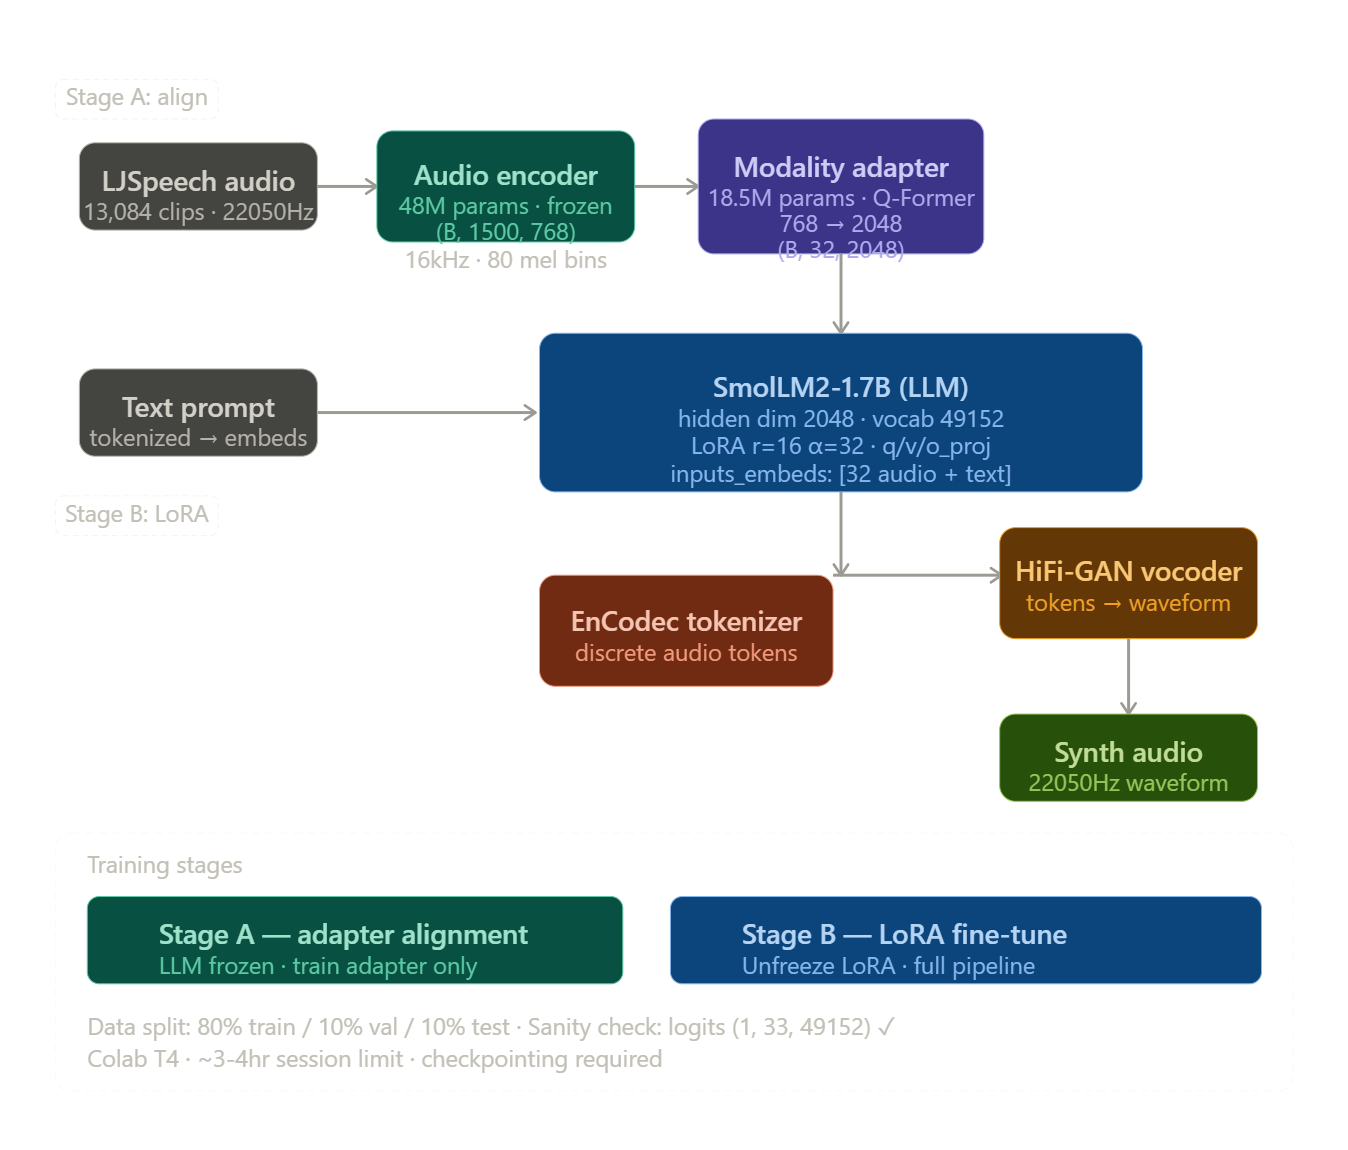

In [8]:
%%capture
!pip install transformers peft accelerate bitsandbytes

In [10]:
from huggingface_hub import notebook_login
notebook_login()  # run this first, paste your HF token

In [15]:
from huggingface_hub import whoami
print(whoami())  # should print your HF username
# if this errors, run notebook_login() again

{'type': 'user', 'id': '6a2059935f415407cf47f077', 'name': 'Aditi412', 'fullname': 'Aditi Jha', 'email': 'aditijha1104@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1782864000, 'isPro': False, 'avatarUrl': '/avatars/a9cbed11bbae85a50f81b8e9c12725c9.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'HF2', 'role': 'write', 'createdAt': '2026-06-15T06:03:16.029Z'}}}


In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

MODEL_ID = "HuggingFaceTB/SmolLM2-1.7B"
# needs HuggingFace token — if gated, use:
#huggingface-cli login    # OR use_auth_token=True

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

llm = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)

config.json:   0%|          | 0.00/635 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [18]:
%%capture
!pip install --upgrade torchao

# Apply LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "o_proj"],  # k_proj excluded to save memory
    bias="none",
)

llm = get_peft_model(llm, lora_config)
llm.print_trainable_parameters()
# expect: ~3-5M trainable / 1B total

In [20]:
# Sanity check — forward pass with fake audio tokens
dummy_audio_tokens = torch.randn(1, 32, 2048).half().to(llm.device)

# Llama expects input_embeds OR input_ids, not both
# At inference: prepend audio tokens to text embeddings
text = tokenizer("Hello", return_tensors="pt").to(llm.device)
text_embeds = llm.model.model.embed_tokens(text.input_ids)  # (1, seq, 2048)

# Concatenate: [audio_tokens | text_tokens]
combined = torch.cat([dummy_audio_tokens, text_embeds], dim=1)  # (1, 34, 2048)

with torch.no_grad():
    out = llm(inputs_embeds=combined)

print("LLM output shape:", out.logits.shape)  # (1, 34, vocab_size)
print("Vocab size:", out.logits.shape[-1])     # 128256 for Llama 3.2

LLM output shape: torch.Size([1, 33, 49152])
Vocab size: 49152
